# 🤖 04 - Gözetimli Makine Öğrenmesi (Segment-Level Classification)
## Uydu Telemetri Anomali Tespiti

**Amaç:** Segment bazlı özellik matrisini kullanarak gözetimli anomali tespiti modellerini eğitmek.

### Modeller:
1. Random Forest (Ensemble)
2. Support Vector Machine (SVM)
3. XGBoost (Gradient Boosting)
4. MLP (Deep Learning)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

import sys
sys.path.insert(0, '..')
from src.models.supervised import SupervisedAnomalyDetector

print('✅ Kütüphaneler ve Model Sınıfı Yüklendi.')

# Gelişmiş Modeller İçin Eklemeler
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


✅ Kütüphaneler ve Model Sınıfı Yüklendi.


---
## 📥 Bölüm 1: Veri Hazırlama


In [2]:
df_features = pd.read_parquet('../data/features/segment_features.parquet')
print(f"📊 Özellik Matrisi: {df_features.shape}")

drop_cols = ['segment', 'anomaly', 'train', 'channel']
feature_cols = [c for c in df_features.columns if c not in drop_cols]
X = df_features[feature_cols].fillna(0)
y = df_features['anomaly']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.15, random_state=42, stratify=y_trainval)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_sm)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print(f"Train (SMOTE): {X_train_s.shape}, Val: {X_val_s.shape}, Test: {X_test_s.shape}")


📊 Özellik Matrisi: (2123, 28)
Train (SMOTE): (2296, 24), Val: (255, 24), Test: (425, 24)


---
## 🌲 Bölüm 2: Random Forest ve XGBoost


In [3]:
detector = SupervisedAnomalyDetector(random_state=42)
rf_model = detector.train_random_forest(X_train_s, y_train_sm, tune=False)
xgb_model = detector.train_xgboost(X_train_s, y_train_sm, X_val_s, y_val)


🌲 Random Forest eğitiliyor...
🚀 XGBoost eğitiliyor...


---
## ⚔️ Bölüm 3: SVM


In [4]:
svm_model = detector.train_svm(X_train_s, y_train_sm, kernel='rbf')


⚔️ SVM (rbf kernel) eğitiliyor...


---
## 🧠 Bölüm 4: MLP (Derin Öğrenme)


🧠 MLP eğitiliyor...
Epoch 1/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8659 - loss: 0.3160 - val_accuracy: 0.9490 - val_loss: 0.2971
Epoch 2/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9286 - loss: 0.1826 - val_accuracy: 0.9608 - val_loss: 0.2194
Epoch 3/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9373 - loss: 0.1572 - val_accuracy: 0.9647 - val_loss: 0.1471
Epoch 4/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9469 - loss: 0.1458 - val_accuracy: 0.9647 - val_loss: 0.1181
Epoch 5/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9569 - loss: 0.1127 - val_accuracy: 0.9569 - val_loss: 0.1275
Epoch 6/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9591 - loss: 0.1101 - val_accuracy: 0.9765 - val_loss: 0.0757
Epoch 7/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9564 - loss: 0.1093 - val_accuracy: 0.9725 - val_loss: 0.0892
Epoch 8/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9599 - loss: 0.1070 - val_accuracy

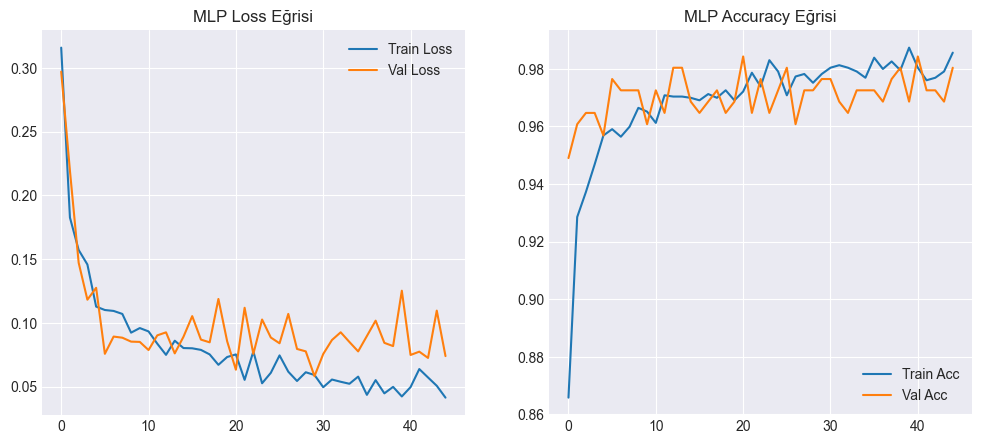

In [5]:
mlp_model, history = detector.train_mlp(X_train_s, y_train_sm.values, X_val_s, y_val.values, epochs=80, batch_size=32)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('MLP Loss Eğrisi'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc'); plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('MLP Accuracy Eğrisi'); plt.legend()
plt.show()


---
## 📊 Bölüm 5: Değerlendirme


In [6]:
detector.evaluate_model('RandomForest', X_test_s, y_test)
detector.evaluate_model('XGBoost', X_test_s, y_test)
detector.evaluate_model('SVM', X_test_s, y_test)
detector.evaluate_model('MLP', X_test_s, y_test.values)

results_df = pd.DataFrame(detector.metrics).T
display(results_df.style.background_gradient(cmap='Blues'))


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


,Accuracy,Precision,Recall,F1_Score,AUC,FAR
RandomForest,0.938824,0.867470,0.827586,0.847059,0.983643,0.032544
XGBoost,0.952941,0.913580,0.850575,0.880952,0.982929,0.020710
SVM,0.943529,0.838710,0.896552,0.866667,0.980446,0.044379
MLP,0.952941,0.903614,0.862069,0.882353,0.985071,0.023669


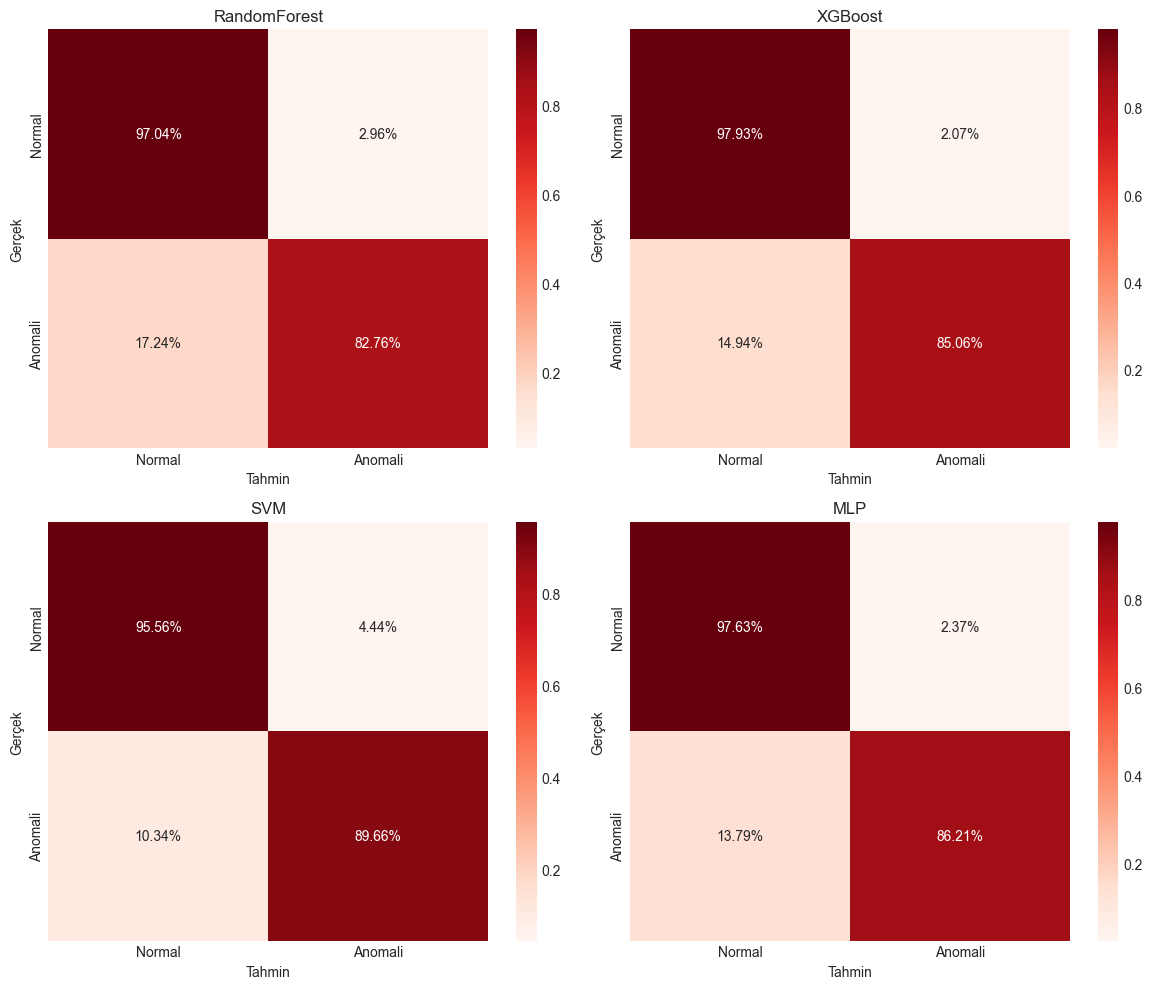

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10)); axes = axes.flatten()
for i, name in enumerate(detector.models.keys()):
    m = detector.models[name]
    yp = (m.predict(X_test_s, verbose=0)>=0.5).astype(int).flatten() if name=='MLP' else m.predict(X_test_s)
    cm = confusion_matrix(y_test, yp, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Reds', ax=axes[i], xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
    axes[i].set_title(name); axes[i].set_xlabel('Tahmin'); axes[i].set_ylabel('Gerçek')
plt.tight_layout(); plt.show()


---
## 🔍 Bölüm 6: ROC Eğrisi


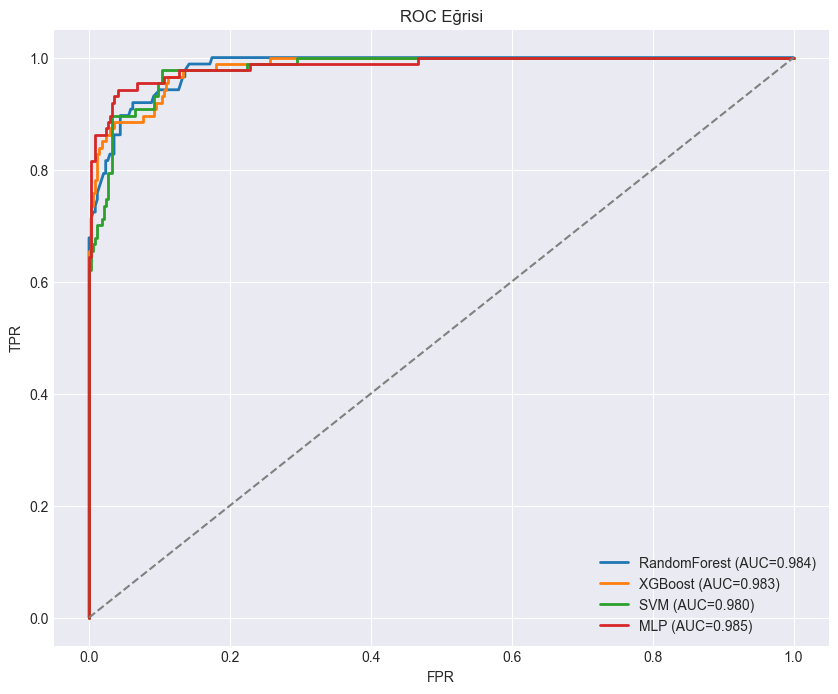

In [8]:
plt.figure(figsize=(10, 8))
for name, model in detector.models.items():
    yp = model.predict(X_test_s, verbose=0).flatten() if name=='MLP' else (model.predict_proba(X_test_s)[:,1] if hasattr(model,'predict_proba') else model.decision_function(X_test_s))
    fpr,tpr,_ = roc_curve(y_test, yp); ra = auc(fpr,tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={ra:.3f})')
plt.plot([0,1],[0,1],color='gray',linestyle='--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Eğrisi'); plt.legend(loc='lower right')
plt.show()


---
## 💾 Bölüm 7: Kaydetme


In [9]:
import joblib
joblib.dump(scaler, '../models/scaler.joblib')
joblib.dump({'X_test': X_test_s, 'y_test': y_test.values, 'feature_cols': feature_cols}, '../models/test_data.joblib')
detector.save_model('RandomForest', '../models/rf_model.joblib')
detector.save_model('XGBoost', '../models/xgb_model.joblib')
detector.save_model('SVM', '../models/svm_model.joblib')
detector.save_model('MLP', '../models/mlp_model.keras')
detector.save_metadata('../reports/metrics/supervised_metrics.json')
print("✅ Tüm modeller ve scaler kaydedildi.")


✅ Model kaydedildi: ../models/rf_model.joblib
✅ Model kaydedildi: ../models/xgb_model.joblib
✅ Model kaydedildi: ../models/svm_model.joblib
✅ Model kaydedildi: ../models/mlp_model.keras
📝 Metadata kaydedildi: ../reports/metrics/supervised_metrics.json
✅ Tüm modeller ve scaler kaydedildi.


### HTML Rapor


In [10]:
%pip install jupyter nbconvert -q
!jupyter nbconvert --to html 04_model_supervised.ipynb --output ../reports/04_model_supervised_rapor.html


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\TAHA\AppData\Local\Programs\Python\Python313\Scripts\jupyter-nbconvert.EXE\__main__.py:4: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
[NbConvertApp] Converting notebook 04_model_supervised.ipynb to html
C:\Users\TAHA\AppData\Local\Programs\Python\Python313\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbfor

## 5. Gelişmiş Modeller (LightGBM, CatBoost & Stacking)\nBu bölümde projenin performansını maksimize etmek için eklenen LightGBM, CatBoost ve Ensemble modelleri bulunmaktadır.

## 2. Model Tanımlamaları ve Eğitim

In [3]:
# LightGBM
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)

# CatBoost
catb = CatBoostClassifier(iterations=300, learning_rate=0.05, random_state=42, verbose=0)

# Stacking Classifier (Meta Model)
# Using strong diverse base learners
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')),
    ('lgbm', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
]
# Meta-learner is LogisticRegression to blend them
stacking = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=3, n_jobs=-1)

models = {
    "LightGBM": lgbm,
    "CatBoost": catb,
    "Stacking Ensemble": stacking
}

print("Eğitim başlıyor...")
trained_models = {}
for name, model in models.items():
    print(f"{name} eğitiliyor...")
    model.fit(X_train, y_train)
    trained_models[name] = model
print("Eğitim tamamlandı!")

Eğitim başlıyor...
LightGBM eğitiliyor...


CatBoost eğitiliyor...


Stacking Ensemble eğitiliyor...


Eğitim tamamlandı!


## 3. Performans Değerlendirme ve Modellerin Kaydedilmesi


--- LightGBM ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       254
           1       0.98      0.95      0.96       253

    accuracy                           0.96       507
   macro avg       0.96      0.96      0.96       507
weighted avg       0.96      0.96      0.96       507


--- CatBoost ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       254
           1       0.98      0.95      0.96       253

    accuracy                           0.96       507
   macro avg       0.96      0.96      0.96       507
weighted avg       0.96      0.96      0.96       507




--- Stacking Ensemble ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       254
           1       0.97      0.95      0.96       253

    accuracy                           0.96       507
   macro avg       0.96      0.96      0.96       507
weighted avg       0.96      0.96      0.96       507



Tüm model dosyaları ve metrikler başarıyla kaydedildi.


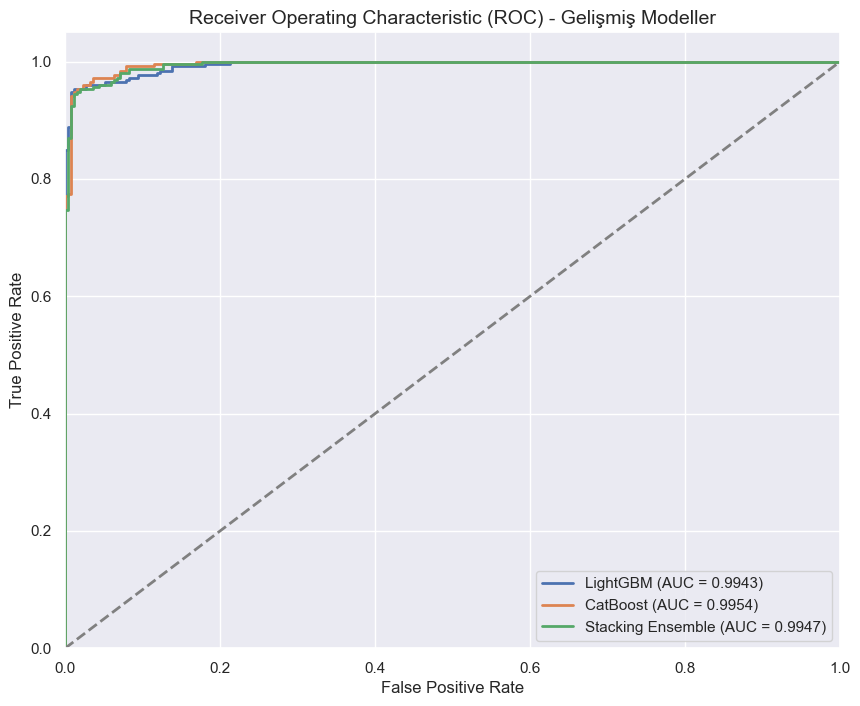

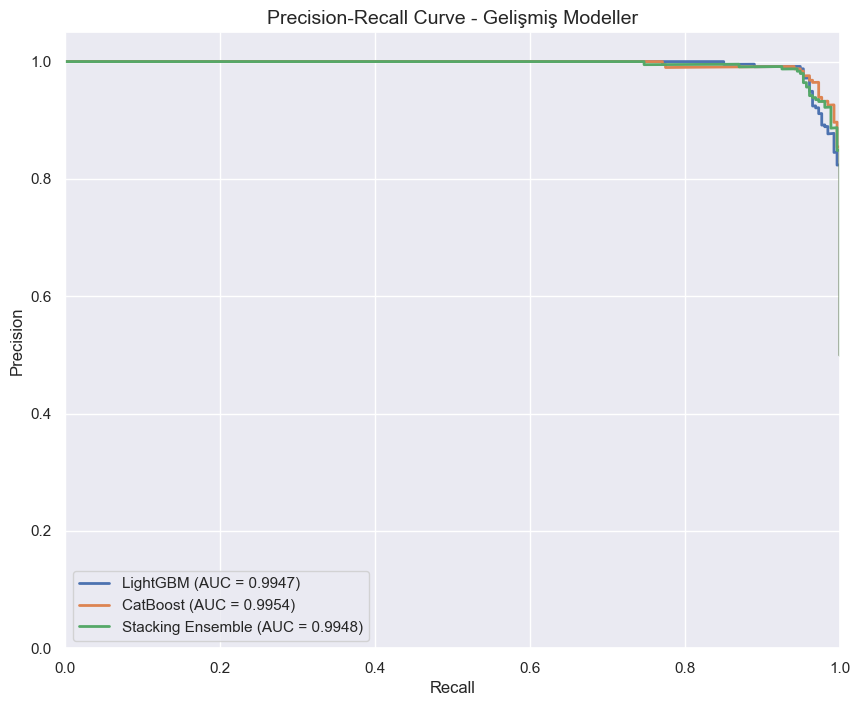

In [4]:
metrics = {}
fig_roc, ax_roc = plt.subplots(figsize=(10, 8))
fig_pr, ax_pr = plt.subplots(figsize=(10, 8))

for name, model in trained_models.items():
    # Tahminler
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrik Hesaplamaları
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    
    metrics[name] = {
        "Accuracy": float(acc),
        "F1 Score": float(f1),
        "ROC AUC": float(roc_auc),
        "PR AUC": float(pr_auc)
    }
    
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))
    
    # Eğrileri Çizdir
    ax_roc.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")
    ax_pr.plot(recall, precision, lw=2, label=f"{name} (AUC = {pr_auc:.4f})")
    
    # Modeli Kaydet
    fname = name.lower().replace(" ", "_") + "_model.joblib"
    joblib.dump(model, os.path.join(MODEL_DIR, fname))

# ROC Eğrisi Finalize Et
ax_roc.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
ax_roc.set_title('Receiver Operating Characteristic (ROC) - Gelişmiş Modeller', fontsize=14)
ax_roc.legend(loc="lower right")
fig_roc.savefig(os.path.join(FIGURES_DIR, "adv_roc_curves.png"), dpi=300, bbox_inches='tight')

# PR Eğrisi Finalize Et
ax_pr.set_xlim([0.0, 1.0])
ax_pr.set_ylim([0.0, 1.05])
ax_pr.set_xlabel('Recall', fontsize=12)
ax_pr.set_ylabel('Precision', fontsize=12)
ax_pr.set_title('Precision-Recall Curve - Gelişmiş Modeller', fontsize=14)
ax_pr.legend(loc="lower left")
fig_pr.savefig(os.path.join(FIGURES_DIR, "adv_pr_curves.png"), dpi=300, bbox_inches='tight')

# Metrikleri JSON'a kaydet (Arayüzde okumak için)
with open(os.path.join(METRICS_DIR, "adv_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=4)
    
print("Tüm model dosyaları ve metrikler başarıyla kaydedildi.")

## 4. Feature Importance Karşılaştırması

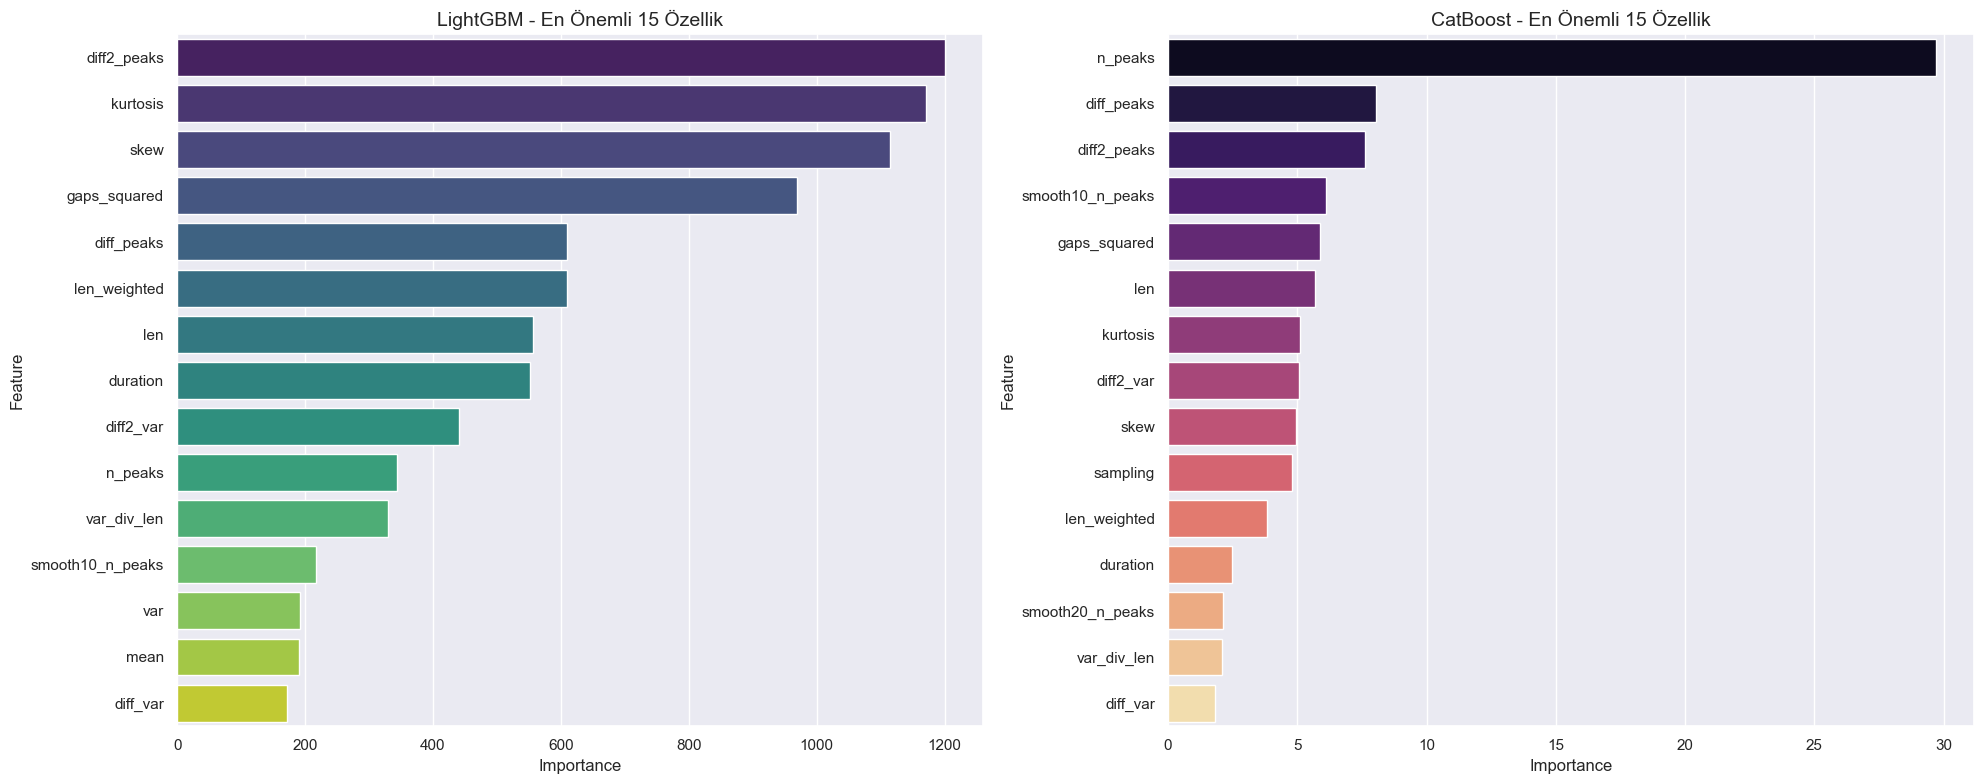

In [5]:
# LightGBM ve CatBoost Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# LGBM
lgbm_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': trained_models['LightGBM'].feature_importances_})
lgbm_imp = lgbm_imp.sort_values(by='Importance', ascending=False).head(15)
sns.barplot(x='Importance', y='Feature', data=lgbm_imp, ax=axes[0], palette='viridis')
axes[0].set_title('LightGBM - En Önemli 15 Özellik', fontsize=14)

# CatBoost
catb_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': trained_models['CatBoost'].get_feature_importance()})
catb_imp = catb_imp.sort_values(by='Importance', ascending=False).head(15)
sns.barplot(x='Importance', y='Feature', data=catb_imp, ax=axes[1], palette='magma')
axes[1].set_title('CatBoost - En Önemli 15 Özellik', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "adv_feature_importance.png"), dpi=300, bbox_inches='tight')
plt.show()